# Set up a batch of ELP simulations

Plan, prepare, and launch a whole CSV of surface-attached ELP simulations —
one row per run. Run the cells in order:

1. **Plan the batch** — point `RUNS_CSV` at the CSV, set everything that is the
   same for every run (and the fallbacks for columns the CSV doesn't have), and
   get a comparison table plus, for each run, its stats and a to-scale
   space-filling plot of the grafting lattice. The per-run stats and plots are
   0/1 opt-ins (`SHOW_STATS`, `SHOW_PLOTS`) — put a `0` behind them for just the
   table.
2. **Prepare + submit to DelftBlue** — checks that every name is unique and
   unused *before* anything is queued, generates `simulations/<name>/` for each
   row, submits them, and appends what went out to `used-runs.csv` in the
   project root.
3. **Prepare + run one row locally (no sbatch/job.sh)** — generates a separate
   `simulations/<name>-<platform>/` for one chosen run and runs it here, as a
   smoke test.

The CSV has one row per run and only holds what differs between runs:

```
Name ;Sequence;concentration;nmolecules;steps;crosslink distance;crosslink prob;mode;walltime
```

Any of those columns may be left out, and any cell may be left blank — it then
falls back to the value set in the planning cell, the same for the whole batch.
`concentration` is always in chains/nm². `Sequence` is either a raw
single-letter sequence (`VPGVGVPGVG…`) or the ELP shorthand `tools/elibpy.py`
uses (`V20`, `K1 V3 (VPGFG) V4` — `<letter><count>` is that many `VPG<letter>G`
repeats, `(FRAGMENT)` is literal). `mode` is how the chains attach to the
surface: blank or `brush` (residue 0 is the fixed anchor — the pipeline as it
always was), `free` or `preattached` (chains hang from surface-bonded lysines;
see `tools/surface.py`). Everything that configures those two modes is in
`shared`, the same for the whole batch.

**How long a run takes** is recorded per simulation in
`runtime/metadata.csv` (`walltime_requested`, `run_wall_seconds`,
`ns_per_hour`, `walltime_used_fraction`), so after the first batch the table in
the planning cell can be compared against what the runs actually cost — which
is what decides whether the next batch is one long job or several short ones.

In [ ]:
# Pick up edits to tools/ without restarting the kernel — otherwise Python keeps
# the module it imported first, and a function added since then is missing.
# (Written as a call rather than %autoreload so the cell is still plain Python.)
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except NameError:
    pass

import matplotlib.pyplot as plt

from tools.run_batch import (
    Shared,
    anchor_bead_diameter,
    surface_kwargs,
    check_names,
    plan_runs,
    plot_lattice,
    print_batch_table,
    print_summary,
    read_runs,
    sequence_notes,
)

# ---- Which runs -----------------------------------------------------------
# One row per simulation. Columns (all optional except Name and Sequence; a
# missing column or a blank cell falls back to `shared` below):
#
#   Name                 becomes simulations/<name>/ — must be unused
#   Sequence             either a raw single-letter sequence (VPGVGVPGVG...) or
#                        the ELP shorthand from tools/elibpy.py: "V20" is 20x
#                        VPGVG, "(VPGFG)" is inserted literally, so
#                        "K1 V3 (VPGFG) V4" is one lysine block + 3 VPGVG +
#                        VPGFG + 4 VPGVG. In brush mode residue 0 becomes the
#                        surface anchor; in the other modes it is an ordinary residue.
#   concentration        ELP chains / nm^2 (this is the only density mode here —
#                        see the note under `shared`)
#   nmolecules           number of chains
#   steps                total MD production steps
#   crosslink distance   nm between two lysines to react; blank = no crosslinking
#   crosslink prob       P(react | within that distance at a check)
#   mode                 how the chains attach to the surface (blank = brush):
#                          brush        residue 0 is tagged "Z" and pinned to its lattice
#                                       point — the pipeline exactly as it always was
#                          free         every chain starts with ONE random lysine bonded
#                                       to the surface; further lysines bind during the
#                                       run when they come within surface_distance of it,
#                                       up to the global cap surface_max_fraction
#                          preattached  a random fraction of ALL lysines is bonded at
#                                       t=0 (at least one per chain) and, by default,
#                                       that set is fixed for the whole run
#                        In free/preattached residue 0 is NOT an anchor: the only thing
#                        holding a chain is its surface-bonded lysine(s). Those bonds
#                        are 3D pins (x, y and z) and never break. See tools/surface.py
#                        for what the results can and cannot be trusted for.
#   preattached fraction preattached mode only: the fraction of all lysines bonded at
#                        t=0 (blank -> surface_preattached_fraction below), so one CSV
#                        can sweep it
#   walltime             SLURM HH:MM:SS for this run's job
RUNS_CSV = "block-runs.csv"

# 0/1 opt-ins for the per-run output. The comparison table always prints; these
# add, for *every* run in the CSV, the full stats block and the to-scale
# space-filling plot of its grafting lattice. Put a 0 behind them when the CSV
# has more runs than you want to scroll through.
SHOW_STATS = 1
SHOW_PLOTS = 1

# ---- Settings shared by every run in the batch -----------------------------
# These are the knobs that are NOT in the CSV, plus the fallbacks for the ones
# that are. Anything the CSV leaves blank is taken from here, so the same value
# applies to the whole batch.
shared = Shared(
    # ---- fallbacks for CSV columns ----
    # How far apart the chains are grafted: an absolute surface concentration in
    # chains/nm^2, i.e. spacing = 1/sqrt(concentration), the same nm whatever the
    # ELP is. (tools.new_simulation also supports spacing-as-a-fraction-of-chain-
    # length and grafted mass per area; a batch mixing density modes wouldn't be
    # comparable row to row, so the CSV route only offers this one.)
    concentration=0.02,                 # ELP chains / nm^2
    nmol=16,                            # number of ELP molecules
    steps=7_070_000,                    # total MD production steps
    walltime="0:40:00",                 # SLURM walltime per job (HH:MM:SS)
    # Reactive crosslinking. None -> nothing reacts, and the run is bit-for-bit
    # identical to the pipeline as it was before this feature existed. A number
    # is the reaction distance in NANOMETRES between two lysine beads: pairs that
    # come closer than this bond permanently *during* the run, so a formed
    # crosslink tethers its chains and changes what happens next. Read the
    # caveats in tools/crosslink.py before interpreting any of it — the sequence
    # and topology of events is meaningful, the rate is not.
    crosslink_distance=None,            # e.g. 0.8 for 8 A
    crosslink_prob=1.0,                 # 1.0 = diffusion-limited; below that the
                                        # reaction rate is decoupled from diffusion
    mode="brush",                       # brush | free | preattached — see the column
                                        # notes above; blank cells fall back to this
    surface_preattached_fraction=None,  # preattached mode: fraction of ALL lysines
                                        # bonded at t=0 (>= chains/lysines, <= the cap)

    # ---- never in the CSV: identical for the whole batch ----
    length_measure="contour",           # what the chain's own length means, for the
                                        # "spacing = x times the chain" readout:
                                        #   "contour" — fully extended, 0.38 nm/bond
                                        #   "coil"    — random walk, 0.38*sqrt(N)
    # Bare surface left between the outermost chains and the box wall, as a
    # fraction of the spacing, on every side (margin = margin_fraction x spacing).
    #   0     default. The lattice tiles the box exactly, so the periodic images
    #         continue it without a seam: a rim chain is half a spacing from the
    #         wall on one side and half a spacing from the *next* box on the
    #         other, i.e. exactly one spacing from its neighbour, as crowded as a
    #         chain in the middle. A uniform infinite grafted surface — but chains
    #         do reach the boundary and get wrapped to the far side of the
    #         trajectory, which looks like them teleporting.
    #   0.5   an edge chain starts a full spacing from the wall instead of half of
    #         one, which stops most of that wrapping. The cost: neighbours across
    #         the boundary are then 2 x spacing apart, so the rim is less crowded
    #         than the middle and the run is a finite grafted patch repeated
    #         periodically rather than a uniform surface.
    #   >0.5  more room still, at the cost of a bigger (slower) box.
    # Worth raising for per-chain observables (Rg, height, RMSD), where a dilute
    # rim barely matters and a readable trajectory does. Leave at 0 for anything
    # that depends on uniform lateral crowding.
    margin_fraction=0,
    # Height of the box, nm. None = 0.3 x the contour length of the chain, and
    # never below 50 nm (tools.new_simulation.plan_box_height). The box is
    # periodic in z as well: the wall is a one-sided potential at the bottom,
    # not a lid, so a bead within the 4 nm cutoff of the top interacts with the
    # periodic image of the grafted layer. The 720-1040-residue blocks reached
    # 51-63 nm in a 50 nm box, i.e. they touched their own image. A taller box
    # costs nothing to speak of. Set a number to override; after a run,
    # metadata.csv's z_max_nm / box_headroom_nm / box_tall_enough say whether
    # it was enough.
    box_height=None,
    # Caps the save interval (steps between saved frames). CALVADOS's own default
    # is 7000; lower it for more temporal resolution at a given step count.
    max_n_save=7000,
    crosslink_valence=1,                # max bonds per lysine. 1 = bifunctional
                                        # crosslinker at 1:1 (glutaraldehyde-like);
                                        # 2 = trifunctional junctions (THPP-like),
                                        # which changes the loop fraction materially
    crosslink_check_every=1000,         # MD steps between reaction checks
    crosslink_k=2000.0,                 # final bond stiffness, kJ/mol/nm^2
    crosslink_r0=0.6,                   # bond equilibrium length, nm
    crosslink_ramp_steps=500,           # steps over which k rises 0 -> crosslink_k,
                                        # so switching a stiff bond on doesn't spike
                                        # the temperature
    crosslink_selection=None,           # None -> auto-detect lysines (LYS, then K,
                                        # then bead name K); residue 0 of each chain
                                        # is always dropped (it is the fixed anchor)
    crosslink_start_step=1_000_000,     # ignore reactions before this step (10 ns).
                                        # Contacts in the early frames are artefacts
                                        # of the initial placement (the free/pre
                                        # construction stacks beads 0.38 nm apart, so
                                        # neighbouring lysines start within the
                                        # reaction distance), not encounters the
                                        # dynamics produced. 10 ns clears those; full
                                        # Rg/RMSD equilibration of the 720-1040-residue
                                        # blocks took 20-60 ns of a 70 ns run (see
                                        # notes_titus), so set this per sequence from
                                        # the Analyze section's check when it matters.
    # Surface attachment through lysines — only used by rows with mode free or
    # preattached, ignored for brush. Siblings of the crosslink_* settings above;
    # all in NANOMETRES. A surface bond is a stiff harmonic tether from the lysine
    # to a fixed point on the "tether plane" z = z_wall + surface_tether, so it
    # holds x, y and z and never breaks. Read tools/surface.py first: CALVADOS has
    # no chemistry here — binding is a distance rule, the sequence of events is
    # meaningful but the rate is not, and surface_distance (like
    # crosslink_distance) dominates the result, so sweep it.
    surface_distance=0.8,               # nm: a free lysine within this vertical distance
                                        # of the tether plane bonds to the surface.
                                        # Separate from crosslink_distance.
    surface_prob=1.0,                   # P(bind | within that distance at a check)
    surface_max_fraction=0.5,           # GLOBAL cap: the largest fraction of ALL lysines
                                        # in the system that may be surface-bonded. Must
                                        # be >= chains / lysines so every chain can have
                                        # its one bond — the planning cell refuses less.
    surface_dynamic=None,               # may lysines bind during the run? None = the
                                        # mode's default (free: yes, preattached: no)
    surface_tether=0.6,                 # nm above the wall onset (z_wall = 1.9 nm) that
                                        # a bound lysine sits — a modelling choice for
                                        # the surface chemistry, so state what you used
    surface_k=2000.0,                   # tether stiffness, kJ/mol/nm^2
    surface_ramp_steps=500,             # steps over which a new tether ramps 0 -> k
    surface_check_every=1000,           # MD steps between binding checks
    surface_start_step=1_000_000,       # ignore binding before this step (10 ns): the
                                        # initial construction leaves beads on the tether
                                        # plane, which would otherwise bind at the first
                                        # check. Same reasoning as crosslink_start_step.
    surface_attraction=0.0,             # kJ/mol depth of an optional lysine-wall well on
                                        # the tether plane; 0 = the wall stays purely
                                        # repulsive (the stock CALVADOS wall)
    surface_seed=None,                  # which lysines are pinned, and where: None =
                                        # drawn and recorded per run (surface.yaml)

    # ---- SLURM (the walltime is per run, in the CSV) ----
    partition="gpu-a100",
    cpu_per_task="18",
)

# Smaller step count for the "run one row locally" smoke-test cell further down.
local_steps = 20_000
# ---------------------------------------------------------------------------

specs = read_runs(RUNS_CSV, shared)
runs = plan_runs(specs, shared)
anchor_sigma = anchor_bead_diameter()   # CALVADOS bead diameter of the anchor residue

print(f"{RUNS_CSV}: {len(runs)} run(s)\n")
print_batch_table(runs)

# Names have to be unique and unused — checked here so a clash shows up while
# planning, and enforced (not just printed) by the submit cell below.
for note in sequence_notes(specs):
    print(f"note: {note}")
problems = check_names(specs)
if problems:
    print("\n⚠  these names can't be submitted as they stand:")
    for problem in problems:
        print(f"   - {problem}")

if SHOW_STATS:
    for run in runs:
        print("\n" + "=" * 78)
        print_summary(run, anchor_sigma)

if SHOW_PLOTS:
    for run in runs:
        plot_lattice(run, anchor_sigma)
        plt.show()

## Prepare + submit to DelftBlue (GPU/SLURM)

Prepares **every run** in `RUNS_CSV` from the planning cell above — one
`simulations/<name>/` per row (config, FASTA, `run.py`, `job.sh`), targeting
CUDA on DelftBlue's GPU partition, each job asking for that row's own walltime.

Before anything is written or queued it checks that every name is free: not
repeated inside the CSV, not already a folder under `simulations/`, and not
already in `used-runs.csv`. If any name is taken the cell stops without
preparing or submitting a single run — a half-submitted batch is worse than a
rejected one, and a duplicate job name would also silently queue behind the old
job (`job.sh` sets `--dependency=singleton`).

`SUBMIT_TO_DELFTBLUE` defaults to `0`, so the folders are generated and the
`sbatch` commands printed, but nothing is queued until you set it to `1` and
rerun. Once the jobs *are* submitted, every one of them is appended to
`used-runs.csv` in the project root — the running list of names and sequences
that have been used, which the check above reads next time.

In [ ]:
import subprocess

from tools.new_simulation import create_simulation
from tools.run_batch import check_names, parse_job_id, record_runs, registry_path, surface_kwargs

SUBMIT_TO_DELFTBLUE = 0  # set to 1 (and rerun) to actually `sbatch` every run in the CSV

# Every name, checked before a single folder is written: duplicated in the CSV,
# already under simulations/, or already in used-runs.csv. All three mean the
# name is taken, and create_simulation would refuse halfway through the loop —
# after earlier rows had already been prepared and queued.
problems = check_names(specs)
if problems:
    raise RuntimeError(
        "Nothing was prepared or submitted. Fix these names first:\n  - "
        + "\n  - ".join(problems)
    )

sim_dirs = {}
for run in runs:
    spec = run.spec
    sim_dirs[spec.name] = create_simulation(
        sequence=spec.sequence,
        concentration=spec.concentration,
        spacing_fraction=None,
        mass_concentration=None,
        length_measure=shared.length_measure,
        margin_fraction=shared.margin_fraction,
        crosslink_distance=spec.crosslink_distance,
        crosslink_prob=spec.crosslink_prob,
        crosslink_valence=shared.crosslink_valence,
        crosslink_check_every=shared.crosslink_check_every,
        crosslink_k=shared.crosslink_k,
        crosslink_r0=shared.crosslink_r0,
        crosslink_ramp_steps=shared.crosslink_ramp_steps,
        crosslink_start_step=shared.crosslink_start_step,
        crosslink_selection=shared.crosslink_selection,
        **surface_kwargs(spec, shared),   # mode + surface_* (brush: no-op)
        nmol=spec.nmol,
        steps=spec.steps,
        name=spec.name,
        platform="CUDA",
        partition=shared.partition,
        walltime=spec.walltime,
        cpu_per_task=shared.cpu_per_task,
        max_n_save=shared.max_n_save,
    )

job_scripts = {name: sim_dir / "runtime" / "job.sh" for name, sim_dir in sim_dirs.items()}

print(f"\n{len(job_scripts)} run(s) ready. To submit by hand (from a DelftBlue login node):")
for job_script in job_scripts.values():
    print(f"  sbatch {job_script}")

if SUBMIT_TO_DELFTBLUE:
    submitted = []
    try:
        for run in runs:
            spec = run.spec
            print(f"\n▶  Submitting to SLURM: {spec.name}  (walltime {spec.walltime})")
            result = subprocess.run(
                ["sbatch", str(job_scripts[spec.name])],
                check=True, capture_output=True, text=True,
            )
            print(f"   {result.stdout.strip()}")
            submitted.append((spec, parse_job_id(result.stdout)))
    finally:
        # In the `finally` so that a batch that fails halfway still records the
        # jobs that did go out — those names are spent either way.
        if submitted:
            path = record_runs(submitted, csv_name=RUNS_CSV)
            print(f"\n✓  {len(submitted)} job(s) submitted and appended to {path}")
else:
    print(f"\nSUBMIT_TO_DELFTBLUE = 0, so nothing was queued and {registry_path().name} "
          f"was not touched.")

## Prepare + run one row locally (no sbatch/job.sh)

Picks **one** run out of the CSV (`LOCAL_RUN` — a name, or an index into the
table printed by the planning cell) and runs it here as a smoke test, for
`local_steps` steps instead of that row's own step count. Generates a separate
`simulations/<name>-<platform>/` (so it never collides with the DelftBlue folder
above) and runs it directly in this notebook — no `sbatch`/`job.sh` involved
either way, and nothing is added to `used-runs.csv`: that list is for jobs that
were actually queued.

Set `platform` to `"CPU"` for a quick sanity check, or `"CUDA"` to run on a GPU
directly.

`"CUDA"` only works where a GPU is actually attached to whatever machine/
kernel this notebook is running on: your own workstation if it has an
NVIDIA GPU, or — on DelftBlue — a compute node you're already attached to
interactively (`srun --partition=gpu-a100 --gpus=1 --pty bash` from a login
node, then launch Jupyter from inside that shell). DelftBlue's login nodes
themselves have no GPU, so `platform="CUDA"` will fail there.

In [ ]:
import subprocess
import sys
from pathlib import Path

from openmm import Context, Platform, System, VerletIntegrator

from tools.new_simulation import _slugify, create_simulation
from tools.run_batch import surface_kwargs

LOCAL_RUN = 0                    # which row of the CSV to smoke-test: its Name, or its index
platform = "CPU"                 # "CPU" or "CUDA" — see markdown above for where "CUDA" actually works

local_spec = (
    runs[LOCAL_RUN].spec if isinstance(LOCAL_RUN, int)
    else next(run.spec for run in runs if run.spec.name == _slugify(LOCAL_RUN))
)

# create_simulation() slugifies its `name` (e.g. "_" -> "-") when it picks the folder
# name — slugify here too so this cell checks/runs the exact same folder it created,
# even if the CSV name contains characters that get normalized away.
local_sim_name = _slugify(f"{local_spec.name}-{platform.lower()}")

if platform == "CUDA":
    # Listing platform names isn't enough — OpenMM reports "CUDA" as compiled-in even
    # with no GPU attached (e.g. on a DelftBlue login node). Actually try to open a
    # device so this fails clearly here instead of deep inside create_simulation/run.py.
    try:
        _probe_system = System()
        _probe_system.addParticle(1.0)
        Context(_probe_system, VerletIntegrator(1.0), Platform.getPlatformByName("CUDA"))
    except Exception as e:
        raise RuntimeError(
            "Could not initialize a CUDA device on this kernel — no GPU is attached here "
            "(see the markdown cell above for how to get one on DelftBlue)."
        ) from e

local_sim_dir = Path("simulations") / local_sim_name
if local_sim_dir.exists():
    print(f"↻  simulations/{local_sim_name}/ already exists — reusing it "
          f"(delete the folder, or change LOCAL_RUN/local_steps, to regenerate).")
else:
    local_sim_dir = create_simulation(
        sequence=local_spec.sequence,
        concentration=local_spec.concentration,
        spacing_fraction=None,
        mass_concentration=None,
        length_measure=shared.length_measure,
        margin_fraction=shared.margin_fraction,
        crosslink_distance=local_spec.crosslink_distance,
        crosslink_prob=local_spec.crosslink_prob,
        crosslink_valence=shared.crosslink_valence,
        crosslink_check_every=shared.crosslink_check_every,
        crosslink_k=shared.crosslink_k,
        crosslink_r0=shared.crosslink_r0,
        crosslink_ramp_steps=shared.crosslink_ramp_steps,
        crosslink_start_step=shared.crosslink_start_step,
        crosslink_selection=shared.crosslink_selection,
        **surface_kwargs(local_spec, shared),   # mode + surface_* (brush: no-op)
        nmol=local_spec.nmol,
        steps=local_steps,
        name=local_sim_name,
        platform=platform,
        max_n_save=shared.max_n_save,
    )

print(f"▶  Running locally on {platform}: {local_sim_dir.name}")
subprocess.run(
    [sys.executable, "-m", f"simulations.{local_sim_dir.name}.runtime.run"],
    check=True,
)

# Analyze results

The cells below load a finished trajectory and measure it. What they are
pointed at is set in the next cell (`ANALYZE`), independently of the setup
section above: **one** simulation name, or a whole runs CSV — a name it cannot
find is reported and skipped, never fatal. Each cell writes its numbers and
figures into that run's own `simulations/<name>/analysis/`.

Work through the section once on a single run, then use the last cell of the
section to repeat all of it for every run in the CSV.


In [ ]:
# Which run(s) this Analyze section looks at. `ANALYZE` accepts:
#
#   "monoblock-test"            one simulation folder under simulations/
#   "block-runs.csv"            every Name in a runs CSV (used-runs.csv, Example-csv.csv, ...)
#   "triblock-64-*"             a pattern, matched against the folders that exist
#   ["a", "b.csv", "c-*"]       any mix of those
#
# Names out of a CSV are slugified exactly the way create_simulation slugifies
# them when it makes the folder, so "My_ELP 2" in the CSV finds
# simulations/my-elp-2/. A name that still doesn't match — a row renamed after
# it was planned, one that was never submitted, one whose job hasn't written a
# trajectory yet — is printed here with the closest folder that does exist, and
# dropped. The runs that *are* there are analyzed as usual: one missing ELP
# never costs you the rest of the batch.
from tools.analysis_batch import resolve_targets

ANALYZE = "monoblock-test"

sim_names = resolve_targets(ANALYZE)

# The cells below analyze one run at a time — this one while you work through
# the section by hand, then each of the others when you run the batch cell at
# the end of it.
sim_name = sim_names[0] if sim_names else None


In [1]:
# Pick up edits to tools/ without restarting the kernel — otherwise Python keeps
# the module it imported first, and a function added since then is missing.
# (Written as a call rather than %autoreload so the cell is still plain Python.)
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except NameError:
    pass

import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt

from tools.analysis_batch import trajectory_paths

if not globals().get("sim_name"):
    raise RuntimeError(
        "No simulation selected — set ANALYZE in the cell above to a simulation "
        "name, a runs CSV or a pattern, and run it."
    )

# Normally runtime/<sim_name>.dcd. trajectory_paths falls back to whatever .dcd
# is actually in runtime/, so a folder renamed after its run still loads, and
# says clearly which file it took.
path_top, path_tra = trajectory_paths(sim_name)
u = mda.Universe(str(path_top), str(path_tra))

from tools.analysis_io import save_text, save_figure

with save_text(sim_name, "load_summary"):

    # Everything below is derived from the topology/trajectory themselves, so the
    # rest of this notebook adapts to whatever PDB it's pointed at (chain count,
    # chain length, box size, which end is anchored) instead of assuming the
    # shape of one specific simulation.
    chains = u.segments
    n_chains = len(chains)

    chain_lengths = {len(seg.residues) for seg in chains}
    if len(chain_lengths) != 1:
        raise ValueError(f"Chains have differing lengths: {sorted(chain_lengths)}")
    n_res_per_chain = chain_lengths.pop()

    box = u.dimensions[:3].copy()  # [x, y, z] in Angstrom, read from the PDB's CRYST1 record

    print(f"{n_chains} chains x {n_res_per_chain} residues/chain, box = {box}")

    def unwrap_in_time(positions):
        """Undo periodic-boundary wrapping so x/y traces are continuous in time.

        The chains are grafted to an infinite surface represented by the periodic
        images, so a molecule that leans across the box edge is written to the
        trajectory translated by exactly one box length — which shows up in a plot
        as the molecule teleporting across the box. The jump is a whole-molecule
        rigid translation, so it can be removed exactly: any frame-to-frame step
        bigger than half a box is a wrap, not motion.

        Note this is only needed for *plotting* coordinates. Distances computed with
        the minimum-image convention (as the crosslinking cells below do) are
        already correct on the wrapped coordinates and must not be unwrapped.
        """
        positions = np.asarray(positions, dtype=float).copy()
        step = np.diff(positions[..., :2], axis=0)
        wraps = np.round(step / box[:2])
        positions[1:, ..., :2] -= np.cumsum(wraps, axis=0) * box[:2]
        return positions

    def get_pos_of_residue(chain_idx, res_idx, unwrap=True):
        """CA position of residue `res_idx` (within-chain) of chain `chain_idx`, across all frames."""
        atom = chains[chain_idx].residues[res_idx].atoms.select_atoms("name CA")
        positions = np.empty((len(u.trajectory), 3))
        for i, ts in enumerate(u.trajectory):
            positions[i] = atom.positions[0]
        return unwrap_in_time(positions) if unwrap else positions

    def track_atoms(atomgroup, unwrap=False):
        """Positions of every atom in `atomgroup`, across all frames: shape (n_frames, n_atoms, 3).

        `unwrap` defaults to False here because the callers below use this for z
        (never wrapped by the DCD writer: it re-centres whole molecules, and a
        chain's centre is far below the box top) and for minimum-image
        distances, neither of which wants it.
        """
        positions = np.empty((len(u.trajectory), len(atomgroup), 3))
        for i, ts in enumerate(u.trajectory):
            positions[i] = atomgroup.positions
        return unwrap_in_time(positions) if unwrap else positions

    # How the chains are attached, from the run's own record (metadata.csv, or
    # surface.yaml if metadata is missing). "brush": residue 0 is the "Z" anchor,
    # zero mass, held fixed on its lattice point. "free" / "preattached": there
    # is no anchor — residue 0 is an ordinary residue and each chain hangs from
    # one or more lysines tethered to the surface, listed in crosslink_events.csv
    # (kind = surface). Every cell below that needs "the bead that holds this
    # chain" uses ref_res_idx, which is the anchor in brush mode and the chain's
    # first initial pin otherwise.
    import csv as _csv
    from pathlib import Path as _Path
    from tools.metadata import read_metadata as _read_metadata
    from tools.surface import mode_of as _mode_of

    _runtime = _Path(f"simulations/{sim_name}/runtime")
    mode = (_read_metadata(_runtime).get("mode") or "").strip() or _mode_of(_runtime)
    empty = u.atoms[:0]

    surface_rows = []
    _events = _runtime / "crosslink_events.csv"
    if _events.is_file():
        with open(_events, newline="") as _f:
            surface_rows = [r for r in _csv.DictReader(_f) if r.get("kind") == "surface"]

    if mode == "brush":
        # Which chain end sits near the surface (small z) vs. dangles freely: found
        # from the trajectory itself rather than assumed, so it stays correct whether
        # the anchor tag was built onto residue 0 or residue -1 of the sequence.
        probe_chains = range(0, n_chains, max(1, n_chains // 5))
        first_end = sum((chains[c].residues[0].atoms.select_atoms("name CA") for c in probe_chains), empty)
        last_end = sum((chains[c].residues[-1].atoms.select_atoms("name CA") for c in probe_chains), empty)
        mean_z_first = track_atoms(first_end)[..., 2].mean()
        mean_z_last = track_atoms(last_end)[..., 2].mean()
        anchor_idx, free_idx = (0, -1) if mean_z_first < mean_z_last else (-1, 0)
        ref_res_idx = np.full(n_chains, anchor_idx % n_res_per_chain)
        print(f"mode brush — anchored end: residue index {anchor_idx} "
              f"(mean z={min(mean_z_first, mean_z_last):.1f} Å); "
              f"free end: residue index {free_idx} (mean z={max(mean_z_first, mean_z_last):.1f} Å)")
    else:
        # No anchor. The reference bead of a chain is its first surface-bonded
        # lysine at t=0 (resid is 1-based within the chain); the C-terminus is
        # reported as "the free end" purely for the plots below — both ends are
        # free in these modes.
        anchor_idx, free_idx = None, -1
        initial_pins = {}
        for r in surface_rows:
            if r.get("origin") == "initial":
                initial_pins.setdefault(int(r["chain_i"]), []).append(int(r["resid_i"]) - 1)
        missing = [c for c in range(n_chains) if c not in initial_pins]
        if missing:
            print(f"!  {len(missing)} chain(s) have no initial surface bond in crosslink_events.csv "
                  f"— using residue 0 as their reference bead")
        ref_res_idx = np.array([min(initial_pins.get(c, [0])) for c in range(n_chains)])
        n_initial = sum(1 for r in surface_rows if r.get("origin") == "initial")
        print(f"mode {mode} — no fixed anchor: residue 0 is an ordinary residue and each chain "
              f"hangs from its surface-bonded lysine(s): {n_initial} bonds at t=0, "
              f"{len(surface_rows) - n_initial} formed during the run "
              f"({len(surface_rows)} of {n_chains * sum(1 for res in chains[0].residues if res.resname == 'LYS')} "
              f"lysines). Reference bead per chain = its first initial pin.")

    # The reference bead cannot move: in brush mode it is a zero-mass particle
    # OpenMM holds fixed; in the lysine modes it is tethered to its pin and only
    # jiggles by ~sqrt(kT/k) ≈ 0.3 Å. Any larger apparent movement is periodic
    # wrapping, and this counts how much of that the trajectory contains.
    reference_all = sum((chains[c].residues[int(ref_res_idx[c])].atoms.select_atoms("name CA")
                         for c in range(n_chains)), empty)
    anchor_all = reference_all
    reference_raw = track_atoms(reference_all)
    surface_z = float(reference_raw[..., 2].mean())   # Å — height of the beads that hold the chains
    n_wraps = int(np.count_nonzero(np.abs(np.diff(reference_raw[..., :2], axis=0)) > box[:2] / 2))
    residual = np.abs(unwrap_in_time(reference_raw) - unwrap_in_time(reference_raw)[0]).max()
    print(f"periodic wrapping: {n_wraps} whole-molecule wrap events in this trajectory "
          f"(reference-bead movement after unwrapping: {residual:.4f} Å — "
          + ("grafted anchors cannot move)" if mode == "brush"
             else "a tethered lysine only jiggles about its pin)"))
    print(f"reference beads sit at z = {surface_z:.1f} Å on average")

    # The box is periodic in z as well as x/y (CALVADOS's nonbonded forces use
    # the periodic cutoff on every axis; the wall is a one-sided potential at
    # the bottom, not a lid). So a bead closer than the 4 nm electrostatics
    # cutoff to the box top interacts with the periodic image of the grafted
    # layer — it is effectively next to the surface again. Check it before
    # trusting anything about the top of the brush.
    z_top_per_frame = np.array([ts.positions[:, 2].max() for ts in u.trajectory])
    z_max = float(z_top_per_frame.max())
    headroom = float(box[2] - z_max)
    cutoff_A = 40.0
    print(f"box height {box[2]:.0f} Å: highest bead ever at z = {z_max:.0f} Å "
          f"(mean per-frame maximum {z_top_per_frame.mean():.0f} Å), headroom {headroom:.0f} Å")
    if headroom < cutoff_A:
        print(f"!  headroom is under the {cutoff_A:.0f} Å nonbonded cutoff: the tallest beads "
              f"interacted with the periodic image of the grafted layer during this run. "
              f"Treat brush-height and top-of-brush results with suspicion and rerun with "
              f"a taller box (box_height in Shared / --box-height).")

/home/tnartey/ELP-Simulations/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FileNotFoundError: [Errno 2] No such file or directory: 'simulations/monoblock-test/runtime/top.pdb'

## Has it equilibrated? (radius of gyration and RMSD)

Run this first on any finished trajectory. It measures two things about the
grafted chains, frame by frame, and shows each of them two ways — **per frame**
(the raw relaxation and its noise) and **cumulative** (the running mean, plus
the reverse cumulative mean, which is flat exactly from the point equilibrium
is reached):

* **Rg**, the size of a chain — how far the coil has collapsed out of its
  extended starting conformation;
* **RMSD** from the first saved frame, measured about each chain's own grafting
  point — how much memory of the starting conformation is left.

They fail differently, which is why both are here: a chain reaches its final
size long before it has forgotten the shape it started in, so the run counts as
equilibrated only once *both* have plateaued, and it is only as well sampled as
the slower of the two.

From that it reports:

* **when** the run equilibrated — the burn-in to discard, chosen by maximising
  the number of independent samples left (Chodera's method),
* **how many independent samples** the rest is worth, given the autocorrelation
  time of each observable — i.e. whether the average is actually supported by
  the data,
* **how long the next run of a comparable sequence needs to be**, which is the
  point of the exercise when screening many sequences.

It leaves `production_start_frame` behind, so the cells below can be restricted
to equilibrated frames with `[production_start_frame:]`.

Time axes come from `runtime/metadata.csv`; if a run predates it, generate it
with `uv run sim metadata <sim_name>` (or `--all`).

In [ ]:
with save_text(sim_name, "equilibration"):
    # ---- Equilibration check: radius of gyration and RMSD over time -----------
    # "Has this run settled down, and how much of it is actually usable?" — so the
    # next sequence can be given the shortest run that still gives good statistics
    # instead of a guessed step count.
    #
    # Two observables, because they fail differently: Rg is the *size* of a chain
    # and says nothing about whether it is still exploring, while RMSD from the
    # starting conformation is pure memory of where it began. A collapsed chain
    # reaches its final Rg long before it has forgotten its initial shape, so the
    # run is equilibrated only once both have plateaued.
    #
    # Each is shown two ways:
    #   normal      the value per frame, averaged over the grafted chains. Shows
    #               the relaxation out of the starting conformation and the noise.
    #   cumulative  the running mean: still drifting while the run is relaxing,
    #               flat once the average has stopped moving. Its mirror image, the
    #               *reverse* cumulative mean (mean of everything after t), is the
    #               sharper test — it is flat from the frame equilibrium is reached,
    #               whereas the forward one drags the burn-in along forever.
    #
    # The equilibration frame itself is picked the standard way (Chodera, JCTC
    # 2016): discard t0 frames, and choose the t0 that leaves the most *independent*
    # samples, N_eff = (N - t0) / g, where g is the statistical inefficiency
    # (1 + 2 x integrated autocorrelation) of what remains. Throwing away too
    # little leaves biased burn-in in the average; throwing away too much leaves
    # too few samples. The maximum of N_eff(t0) is the trade-off point.

    import numpy as np
    import matplotlib.pyplot as plt

    from tools.metadata import as_float, read_metadata

    MIN_EFFECTIVE_SAMPLES = 50      # below this the production window is too short to average over
    TARGET_EFFECTIVE_SAMPLES = 100  # what the "how long should the next run be" estimate aims for


    def chain_observables(universe, segments, box_dims, ref_idx):
        """Per-chain Rg and RMSD for every frame — two (n_frames, n_chains) arrays, in nm.

        Three things this has to get right:

        * Periodic images. A chain leaning over the box edge is written to the DCD
          wrapped, and a naive Rg on those coordinates is nonsense. Bonds are ~0.38
          nm and the box is tens of nm, so walking along the backbone and taking the
          minimum image of every bond vector rebuilds the chain exactly, whether the
          trajectory wrapped it as a whole or split it.
        * Whole-molecule wrapping, for the RMSD specifically. A chain that leans
          across the boundary is written translated by a whole box vector, which
          would swamp any RMSD to an earlier frame. Coordinates are therefore taken
          relative to the chain's own reference bead (`ref_idx`, one per chain: the
          grafted anchor in brush mode, the first surface-bonded lysine in the
          free/preattached modes), which cannot move — so the relative coordinates
          are wrap-free, and the RMSD measures purely how far the chain has moved
          from the conformation it started in.
        * Mass weighting. In brush mode the anchor bead is tagged "Z" and carries
          mass 0 (that is what pins it), so a mass-weighted Rg would silently drop
          the one bead that defines the grafting point. These are the geometric
          quantities — every bead counts once.

        No rotational superposition is done: the surface and the fixed reference
        bead give the chain a real frame of reference, so swinging around the
        attachment point is genuine motion to be sampled, not a nuisance degree of
        freedom to fit away. The RMSD reference is the first *saved* frame.
        """
        index = np.array([seg.atoms.indices for seg in segments])  # (n_chains, n_beads)
        ref_idx = np.asarray(ref_idx, dtype=int)
        rows = np.arange(len(segments))
        n_frames = len(universe.trajectory)
        rg = np.empty((n_frames, len(segments)))
        rmsd = np.empty((n_frames, len(segments)))
        reference = None

        for i, _ts in enumerate(universe.trajectory):
            pos = universe.atoms.positions[index]              # (n_chains, n_beads, 3), Angstrom
            bond = np.diff(pos, axis=1)
            bond -= np.round(bond / box_dims) * box_dims       # minimum image, bond by bond
            whole = np.concatenate(
                [pos[:, :1], pos[:, :1] + np.cumsum(bond, axis=1)], axis=1
            )
            anchored = whole - whole[rows, ref_idx][:, None, :]   # relative to the held bead

            dev = anchored - anchored.mean(axis=1, keepdims=True)
            rg[i] = np.sqrt((dev ** 2).sum(axis=2).mean(axis=1))

            if reference is None:
                reference = anchored.copy()
            rmsd[i] = np.sqrt(((anchored - reference) ** 2).sum(axis=2).mean(axis=1))

        return rg / 10.0, rmsd / 10.0  # Angstrom -> nm


    def statistical_inefficiency(series):
        """g = 1 + 2 * sum_t (1 - t/N) C(t), truncated at the first non-positive C(t).

        g is how many frames one independent sample is worth: N frames of a
        correlated series carry only N/g of the information of N independent ones.
        """
        x = np.asarray(series, dtype=float)
        n = len(x)
        if n < 3:
            return 1.0
        dx = x - x.mean()
        var = dx.dot(dx) / n
        if var <= 0:
            return 1.0
        g = 1.0
        for lag in range(1, n - 1):
            c = dx[:-lag].dot(dx[lag:]) / ((n - lag) * var)
            if c <= 0 and lag > 1:
                break
            g += 2.0 * c * (1.0 - lag / n)
        return max(1.0, g)


    def detect_equilibration(series, n_candidates=200):
        """(t0, g, n_eff, candidates, n_eff_curve) — burn-in length maximising independent samples."""
        n = len(series)
        if n < 10:
            return 0, 1.0, float(n), np.array([0]), np.array([float(n)])
        candidates = np.unique(np.linspace(0, int(0.9 * n), min(n_candidates, n)).astype(int))
        n_eff_curve = np.array([(n - t0) / statistical_inefficiency(series[t0:]) for t0 in candidates])
        best = int(candidates[int(np.argmax(n_eff_curve))])
        g = statistical_inefficiency(series[best:])
        return best, g, (n - best) / g, candidates, n_eff_curve


    def analyse(series):
        """Everything the plots and the printout need about one observable's time series."""
        n = len(series)
        t0, g, n_eff, candidates, n_eff_curve = detect_equilibration(series)
        production = series[t0:]
        mean = production.mean()
        sem = production.std(ddof=1) / np.sqrt(max(n_eff, 1.0))  # error on *independent* samples
        half = len(production) // 2
        drift = (abs(production[:half].mean() - production[half:].mean()) / (sem * np.sqrt(2))
                 if half and sem > 0 else 0.0)
        return {
            "series": series,
            "t0": t0, "g": g, "n_eff": n_eff, "mean": mean, "sem": sem, "drift": drift,
            "candidates": candidates, "n_eff_curve": n_eff_curve,
            "cumulative": np.cumsum(series) / np.arange(1, n + 1),
            "reverse_cumulative": (np.cumsum(series[::-1]) / np.arange(1, n + 1))[::-1],
        }


    # ---- time axis: real simulated time when metadata.csv is there, frames otherwise ----
    meta = read_metadata(f"simulations/{sim_name}/runtime")
    ns_per_frame = as_float(meta, "time_per_frame_ps", default=np.nan) / 1000.0
    if not np.isfinite(ns_per_frame) or ns_per_frame <= 0:
        ns_per_frame = np.nan
        print("!  no runtime/metadata.csv for this run — showing frames instead of ns "
              f"(run 'uv run sim metadata {sim_name}' to generate it).")

    rg_per_chain, rmsd_per_chain = chain_observables(u, chains, box, ref_res_idx)
    per_chain = {"Rg": rg_per_chain, "RMSD": rmsd_per_chain}
    results = {name: analyse(values.mean(axis=1)) for name, values in per_chain.items()}
    n_frames = len(rg_per_chain)

    # Smoke tests are a fraction of a nanosecond and production runs are tens of
    # them, so the time unit follows the run rather than being fixed at ns.
    use_time = np.isfinite(ns_per_frame)
    if not use_time:
        time_unit, unit_per_frame = "frames", 1.0
    elif n_frames * ns_per_frame >= 1.0:
        time_unit, unit_per_frame = "ns", ns_per_frame
    else:
        time_unit, unit_per_frame = "ps", ns_per_frame * 1000.0

    x = np.arange(n_frames) * unit_per_frame
    xlabel = f"simulated time ({time_unit})" if use_time else "frame"


    def fmt_t(frames):
        """A duration given in frames, printed in whatever unit suits this run."""
        return f"{frames * unit_per_frame:.2f} {time_unit}" if use_time else f"frame {frames:.0f}"


    # The run is only equilibrated once *both* observables are, and it is only as
    # well sampled as its slowest mode — so the recommendation takes the worst case.
    t0 = max(r["t0"] for r in results.values())
    g_slowest = max(r["g"] for r in results.values())
    n_eff_worst = min(r["n_eff"] for r in results.values())
    drift_worst = max(r["drift"] for r in results.values())

    print(f"simulation:        {sim_name}")
    print(f"trajectory:        {n_frames} frames, {n_chains} chains x {n_res_per_chain} residues"
          + (f", {fmt_t(n_frames)} total" if use_time else ""))
    print()
    print(f"{'':<6} {'equilibrated after':>20} {'correlation time':>18} {'N_eff':>7} "
          f"{'plateau (nm)':>18} {'drift':>8}")
    for name, r in results.items():
        plateau = f"{r['mean']:.3f} +/- {r['sem']:.3f}"
        print(f"{name:<6} {fmt_t(r['t0']):>20} {fmt_t(r['g']):>18} {r['n_eff']:>7.0f} "
              f"{plateau:>18} {r['drift']:>7.1f}σ")
    print(f"\nburn-in to discard: {t0} frames ({fmt_t(t0)}) = {100 * t0 / n_frames:.0f}% of the run "
          f"— the later of the two")

    if t0 >= 0.9 * n_frames - 1:
        print("\n⚠  NOT EQUILIBRATED — still moving at the end of the trajectory. Nothing here is safe "
              "to average; this run needs to be longer.")
    elif n_eff_worst < MIN_EFFECTIVE_SAMPLES:
        print(f"\n⚠  equilibrated, but only {n_eff_worst:.0f} independent samples of the slowest "
              f"observable — averages are usable with caution and error bars will be wide.")
    elif drift_worst > 2:
        print(f"\n⚠  {drift_worst:.1f}σ of drift remains after the cut — a slow mode is still relaxing. "
              f"Treat the plateau values as provisional.")
    else:
        print(f"\n✓  equilibrated after {fmt_t(t0)}, with {n_eff_worst:.0f} independent samples to "
              f"average over.")

    # How long the *next* run of a sequence like this needs to be: the burn-in it
    # takes to equilibrate, plus enough correlation times to average properly.
    needed_frames = t0 + TARGET_EFFECTIVE_SAMPLES * g_slowest
    steps_per_frame = as_float(meta, "steps_per_frame", default=np.nan)
    total_steps = as_float(meta, "total_steps", default=np.nan)
    if np.isfinite(steps_per_frame):
        needed_steps = int(np.ceil(needed_frames * steps_per_frame / 1000) * 1000)
        verdict = "shorter" if needed_steps < total_steps else "longer"
        print(f"\nnext run of this sequence: ~{needed_steps:,} steps ({fmt_t(needed_frames)}) for "
              f"N_eff = {TARGET_EFFECTIVE_SAMPLES} — {verdict} than the {int(total_steps):,} steps "
              f"this run used.")
        print(f"   (burn-in {fmt_t(t0)} + {TARGET_EFFECTIVE_SAMPLES} x {fmt_t(g_slowest)}; longer "
              f"chains and tighter spacings relax more slowly, so re-check per sequence.)")

    # Frames the rest of the notebook should average over. Slice any per-frame
    # array below with [production_start_frame:] to drop the burn-in.
    production_start_frame = t0

    # ---- plots: one column per observable -------------------------------------
    fig, axes = plt.subplots(3, 2, figsize=(14, 11), constrained_layout=True)

    for col, (name, r) in enumerate(results.items()):
        values = per_chain[name]
        unit = f"{name} (nm)"

        ax = axes[0, col]
        for c in range(values.shape[1]):
            ax.plot(x, values[:, c], color="#4c72b0", alpha=0.15, linewidth=0.6)
        ax.plot(x, r["series"], color="#1f3a63", linewidth=1.4, label=f"{name} (mean over chains)")
        ax.axvspan(x[r["t0"]], x[-1], color="#55a868", alpha=0.10, label="production window")
        ax.axvline(x[r["t0"]], color="#c44e52", linestyle="--", linewidth=1.2,
                   label=f"equilibrated at {fmt_t(r['t0'])}")
        ax.axhline(r["mean"], color="#55a868", linewidth=1.2, label=f"plateau = {r['mean']:.2f} nm")
        ax.set_ylabel(unit)
        ax.set_xlabel(xlabel)
        ax.set_title(f"{name} per frame — {sim_name}\n(faint = individual chains)", fontsize=10)
        ax.legend(fontsize=8, loc="best")

        ax = axes[1, col]
        ax.plot(x, r["cumulative"], color="#dd8452", linewidth=1.5,
                label="cumulative mean (all frames up to t)")
        ax.plot(x, r["reverse_cumulative"], color="#4c72b0", linewidth=1.5,
                label="reverse cumulative mean (frames after t)")
        ax.axhline(r["mean"], color="#55a868", linewidth=1.2, label=f"plateau = {r['mean']:.3f} nm")
        ax.fill_between(x, r["mean"] - r["sem"], r["mean"] + r["sem"], color="#55a868", alpha=0.20,
                        label="+/- 1 SEM")
        ax.axvline(x[r["t0"]], color="#c44e52", linestyle="--", linewidth=1.2)
        # The first few frames of the cumulative mean carry the whole starting-structure
        # transient and would squash the plateau — the interesting part — into a line.
        tail = slice(max(1, n_frames // 50), None)
        lo = min(r["cumulative"][tail].min(), r["reverse_cumulative"][tail].min(), r["mean"] - 3 * r["sem"])
        hi = max(r["cumulative"][tail].max(), r["reverse_cumulative"][tail].max(), r["mean"] + 3 * r["sem"])
        pad = 0.08 * (hi - lo) or 0.02 * max(r["mean"], 1e-9)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_ylabel(f"cumulative {unit}")
        ax.set_xlabel(xlabel)
        ax.set_title(f"{name}: cumulative vs reverse-cumulative (zoomed on the plateau)\n"
                     f"equilibrium is where the reverse curve goes flat", fontsize=10)
        ax.legend(fontsize=8, loc="best")

        ax = axes[2, col]
        ax.plot(r["candidates"] * unit_per_frame, r["n_eff_curve"], color="#8172b3", linewidth=1.5)
        ax.axvline(x[r["t0"]], color="#c44e52", linestyle="--", linewidth=1.2,
                   label=f"best t0 = {fmt_t(r['t0'])} -> N_eff = {r['n_eff']:.0f}")
        ax.axhline(MIN_EFFECTIVE_SAMPLES, color="#c44e52", linestyle=":", linewidth=1.0,
                   label=f"N_eff = {MIN_EFFECTIVE_SAMPLES} (minimum for a useful average)")
        ax.set_xlabel(f"burn-in discarded ({time_unit})")
        ax.set_ylabel("independent samples left")
        ax.set_title(f"{name}: independent samples surviving each choice of burn-in", fontsize=10)
        ax.legend(fontsize=8, loc="best")

    save_figure(sim_name, "equilibration", fig)
    plt.show()


## Amino acid distribution along z

Pick a single-letter amino acid code (`aa_letter`, matching the `one` column
of `residues_CALVADOS2.csv`) and see how that residue type is distributed
across the z-height, pooled over every chain and every saved frame from
`start_frame` onward (raise `start_frame` to drop early/equilibration
frames from the histogram).

In [ ]:
import csv

import numpy as np
import matplotlib.pyplot as plt

aa_letter = "K"    # single-letter amino acid code to inspect (see residues_CALVADOS2.csv "one" column)
start_frame = 600    # first saved frame to include (0-based) — raise this to skip equilibration frames

# one-letter -> three-letter resname, from the same CALVADOS residue table used to build the topology
one_to_three = {}
with open("residues_CALVADOS2.csv", newline="") as f:
    for row in csv.DictReader(f):
        one_to_three[row["one"]] = row["three"]
if aa_letter not in one_to_three:
    raise ValueError(f"Unknown amino acid letter {aa_letter!r} — see residues_CALVADOS2.csv")
target_resname = one_to_three[aa_letter]

# In brush mode the surface anchor (residue anchor_idx of every chain) is relabelled
# "Z" in the topology regardless of the original sequence letter, and "Z" reuses
# valine's resname/sigma — exclude those beads so a query for "V" isn't contaminated
# by the (wall-constrained) anchors. In the free/preattached modes there is no
# anchor and every bead is what the sequence says.
target_ca = u.select_atoms(f"name CA and resname {target_resname}")
if anchor_idx is not None:
    anchor_ca = sum(
        (chains[c].residues[anchor_idx].atoms.select_atoms("name CA") for c in range(n_chains)),
        empty,
    )
    target_ca = target_ca - anchor_ca

from tools.analysis_batch import SkipRest

if len(target_ca) == 0:
    # sim_name here is independent of any sequence built earlier in the notebook —
    # this trajectory simply may never have contained an '{aa_letter}'. Show what it
    # actually does contain so that's obvious instead of a guessing game.
    present = sorted({res.resname for res in chains[0].residues})
    # SkipRest, not an error: a run of a sequence without this residue is a
    # perfectly good run, it just has nothing for this section. In a batch that
    # ends this run quietly and moves on to the next one.
    raise SkipRest(
        f"No non-anchor '{aa_letter}' ({target_resname}) residues found in trajectory "
        f"'{sim_name}'. Residue types actually present in this trajectory: {present}. "
        f"(A sequence without '{aa_letter}' has nothing for this cell or the crosslink "
        f"cells below; in a batch that run is noted and the next one carries on.)"
    )

if start_frame < 0:
    raise ValueError(f"start_frame={start_frame} must not be negative.")
if start_frame >= len(u.trajectory):
    # Shorter run than the one start_frame was chosen for (a batch mixes run
    # lengths). Halving is a guess, so it says so rather than quietly using it.
    start_frame = len(u.trajectory) // 2
    print(f"!  start_frame is past the end of this {len(u.trajectory)}-frame trajectory — "
          f"using frame {start_frame} (its second half) instead")

z_all_full = track_atoms(target_ca)[..., 2]  # shape (n_frames, n_target_atoms), every saved frame
z_all = z_all_full[start_frame:]             # frames >= start_frame; also used by the cumulative-average cell below
anchor_z = surface_z   # Å — mean height of the beads that hold the chains (see the load cell)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(z_all.ravel(), bins=60, density=True, color="#4c72b0", alpha=0.8)
ax.axvline(anchor_z, color="black", linestyle="--", linewidth=1,
           label="anchor z" if mode == "brush" else "surface-bonded lysines z")
ax.set_xlabel("z (Å)")
ax.set_ylabel("probability density")
ax.set_title(f"{sim_name}: z-distribution of '{aa_letter}' ({target_resname}), "
             f"{target_ca.n_atoms} residues x {z_all.shape[0]}/{z_all_full.shape[0]} frames "
             f"(from frame {start_frame})")
ax.legend()
save_figure(sim_name, f"z_distribution_{aa_letter}", fig)
plt.show()


## Cumulative average distribution over time (equilibration check)

Uses `z_all` from the cell above (i.e. already restricted to frames >=
`start_frame` — frame indices below are relative to that offset). Shows the
z-distribution of `aa_letter` built from only the first `t` frames, for
growing `t`, plus how far that cumulative-average distribution still is from
the full-trajectory one (total-variation distance). Once the distance
settles near zero, adding more frames no longer changes the distribution —
i.e. the simulation has become stable for this residue.

In [ ]:
with save_text(sim_name, f"z_distribution_{aa_letter}_convergence"):
    n_frames_total, n_target_atoms = z_all.shape

    n_bins = 60
    bins = np.linspace(0, box[2], n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width = bins[1] - bins[0]

    # Per-frame counts, then cumulative over frames -> a density profile built from
    # only frames [0, t] for every t, each normalized to integrate to 1 on its own.
    per_frame_counts = np.array(
        [np.histogram(z_all[t], bins=bins)[0] for t in range(n_frames_total)], dtype=float
    )
    cum_counts = np.cumsum(per_frame_counts, axis=0)
    cum_density = cum_counts / (cum_counts.sum(axis=1, keepdims=True) * bin_width)
    final_density = cum_density[-1]  # profile from the whole trajectory

    # Total-variation distance between the cumulative profile up to frame t and the
    # full-trajectory profile: how much the "average so far" still has left to move.
    drift = np.abs(cum_density - final_density).sum(axis=1) * bin_width

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    ax = axes[0]
    checkpoints = np.unique(np.linspace(0, n_frames_total - 1, min(8, n_frames_total), dtype=int))
    cmap = plt.get_cmap("viridis")
    for i, t in enumerate(checkpoints):
        ax.plot(bin_centers, cum_density[t], color=cmap(i / max(1, len(checkpoints) - 1)),
                label=f"frames 0-{t + 1}")
    ax.set_xlabel("z (\u00c5)")
    ax.set_ylabel("cumulative probability density")
    ax.set_title(f"'{aa_letter}' z-distribution, cumulative average over time")
    ax.legend(fontsize=7, ncol=2)

    ax = axes[1]
    ax.plot(np.arange(1, n_frames_total + 1), drift, color="#c44e52")
    ax.set_xlabel("frame index")
    ax.set_ylabel("TV distance to full-trajectory profile")
    ax.set_title("convergence of the cumulative distribution")

    # Heuristic "stable after" point: the first frame beyond which drift never
    # exceeds `tol` again (tail-anchored, so an early lucky dip isn't flagged).
    tol = 0.05
    above_tol = np.nonzero(drift > tol)[0]  # 0-indexed frames still above tolerance
    if above_tol.size == 0:
        stable_frame = 1
    elif above_tol[-1] == n_frames_total - 1:
        stable_frame = None
    else:
        stable_frame = above_tol[-1] + 2  # 1-indexed frame right after the last violation

    if stable_frame is not None:
        ax.axvline(stable_frame, color="black", linestyle="--", linewidth=1)
        ax.text(stable_frame, drift.max(), f" stable from frame {stable_frame}", va="top")
        print(f"'{aa_letter}' z-distribution looks stable (TV distance <= {tol}) from frame "
              f"{stable_frame}/{n_frames_total} onward.")
    else:
        print(f"'{aa_letter}' z-distribution never settles within TV distance {tol} of the "
              f"full-trajectory profile \u2014 try a looser tol, more sampling, or check for a slow drift.")

    fig.tight_layout()
    save_figure(sim_name, f"z_distribution_{aa_letter}_convergence", fig)
    plt.show()


## Free-end 3D trajectories

The path traced by the free end (residue index `free_idx` — the end
*opposite* the surface anchor in brush mode; in the free/preattached modes both
ends are free and this is the C-terminus) of a sample of `max_chains_3d` chains, across
every saved frame — one colored line per chain. Axes are box coordinates in
Å, scaled to the actual simulation box (`box[0] x box[1] x box[2]`) so you
can see how much of the box each chain's free end actually explores, and
whether that exploration stays close to the surface (small z, near the
dashed anchor level used in later cells) or wanders throughout the box.

In [ ]:
fig = plt.figure()
ax = plt.axes(projection='3d')

max_chains_3d = 15
sample_chain_idx = np.linspace(0, n_chains - 1, min(max_chains_3d, n_chains), dtype=int)

trajectories = []
for c in sample_chain_idx:
    positions = get_pos_of_residue(c, free_idx)
    trajectories.append(positions)

    ax.plot3D(positions[:, 0], positions[:, 1], positions[:, 2], alpha=.5)

# Coordinates are unwrapped (see unwrap_in_time), so a chain leaning across the
# box edge continues smoothly past it instead of teleporting back — which means
# x/y can legitimately fall outside [0, box]. Widen the limits to whatever the
# traces actually cover, keeping the box itself in view for reference.
xy = np.concatenate(trajectories)[:, :2]
ax.axes.set_xlim3d([min(0, xy[:, 0].min()), max(box[0], xy[:, 0].max())])
ax.axes.set_ylim3d([min(0, xy[:, 1].min()), max(box[1], xy[:, 1].max())])
ax.axes.set_zlim3d([0, box[2]])
ax.set_xlabel("x (Å)")
ax.set_ylabel("y (Å)")
ax.set_zlabel("z (Å)")
ax.set_title(f"{sim_name}: free-end (residue {free_idx}) trajectory of {len(sample_chain_idx)}/{n_chains} chains")
save_figure(sim_name, "free_end_3d", fig)
plt.show()


## Free-end x/y/z coordinates over time, per chain

Same sample of chains as the 3D plot above, but split into individual x, y,
and z coordinate traces (rows) against frame number (columns = chains), so
you can read off each axis separately instead of untangling a 3D plot. The
dashed line on the z row is `anchor_z` — the mean z of the beads that hold the
chains (the anchored end in brush mode, the surface-bonded lysines otherwise;
from the "load trajectory" cell) — so you can see at a glance how far each
chain's free end sits above the surface, and whether it drifts, oscillates,
or has settled into a steady range over the run. This renders once from the
already-loaded trajectory (not a live view), so it does not need to keep
running after it draws.

In [ ]:
max_chains_grid = 10
grid_chain_idx = np.linspace(0, n_chains - 1, min(max_chains_grid, n_chains), dtype=int)
n_cols = len(grid_chain_idx)

anchor_z = surface_z  # reference line: mean z of the beads holding the chains
axis_labels = ["x (Å)", "y (Å)", "z (Å)"]
colors = ["red", "green", "blue"]

fig, axs = plt.subplots(3, n_cols, figsize=(3 * n_cols, 6), squeeze=False, sharex=True)

for i, c in enumerate(grid_chain_idx):
    positions = get_pos_of_residue(c, free_idx)
    axs[0, i].set_title(f"chain {chains[c].segid}")

    for j in range(3):
        axs[j, i].plot(positions[:, j], color=colors[j])
        axs[j, i].grid()
        if i == 0:
            axs[j, i].set_ylabel(axis_labels[j])
        if j == 2:
            axs[j, i].set_xlabel("frame index")

    axs[2, i].axhline(anchor_z, color="black", linestyle="--", linewidth=1,
                       label=("anchor z (mean)" if mode == "brush" else "bonded-lysine z (mean)")
                       if i == 0 else None)

axs[2, 0].legend(fontsize=7, loc="upper right")
fig.suptitle(f"{sim_name}: free-end (residue {free_idx}) x/y/z coordinates over time, "
             f"{n_cols}/{n_chains} chains")
fig.tight_layout()
save_figure(sim_name, "free_end_xyz_grid", fig)
plt.show()


## Crosslinking contacts: same polymer vs. different polymers

Counts how often a pair of crosslinkable residues (`contact_letters`, e.g.
`"K"` for the lysines) sits closer than `contact_cutoff`, and splits those
hits into pairs belonging to the **same chain** (intra-chain, an
intramolecular crosslink) and pairs belonging to **two different chains**
(inter-chain, the one that actually builds a network).

Distances are minimum-image, so a pair that meets around the periodic x/y
edge of the box still counts. Anchor beads (brush mode) are excluded, and intra-chain
pairs closer than `min_seq_separation` residues along the backbone are
dropped (backbone neighbours are trivially close and cannot crosslink).

Two numbers answer two different questions, and they can point opposite ways:

* **P(pair in contact)** — hits divided by (pairs x frames), i.e. how likely
  *one given pair* is to be in contact. This is the per-pair propensity, and
  it is the fair comparison: it is not inflated by the fact that `n` chains
  offer far more inter-chain pairs than intra-chain ones.
* **share of all contacts** — the raw hit counts, which is what a bulk
  crosslinking experiment integrates over. With many chains, inter-chain
  crosslinks can dominate the total even when each individual inter-chain
  pair is much less likely to meet.

Chains that leaned across a periodic edge are written wrapped to the far side
of the box. That does **not** lose contacts: the distances below are computed
with `box=ts.dimensions`, i.e. the minimum-image convention on every axis, so a
lysine pair touching across the boundary is counted exactly like one in the
middle of the box. The live crosslinker in the run uses the same rule. Do not
pass unwrapped coordinates here, and do not drop the `box=` argument.


In [2]:
import csv

import numpy as np
from MDAnalysis.lib.distances import self_distance_array

# ---- Inputs --------------------------------------------------------------
contact_letters = ["K"]      # single-letter code(s) of the crosslinkable residue(s), e.g. ["K"] or ["K", "Y"]
contact_cutoff = 14.0        # Å — a pair sitting closer than this counts as one "hit" (crosslinkable contact)
min_seq_separation = 4       # ignore intra-chain pairs fewer than this many residues apart in the sequence
                             # (neighbours along the backbone are trivially close and can't crosslink)
contact_start_frame = 0      # first saved frame to include (0-based) — raise to skip equilibration
hist_max = 60.0              # Å — largest distance kept in the distance histogram / cutoff scan
hist_bin = 0.5               # Å — histogram bin width (also the resolution of the cutoff scan)
# ---------------------------------------------------------------------------

with save_text(sim_name, f"crosslink_contacts_{'_'.join(contact_letters)}"):
    # one-letter -> three-letter resname, re-read here so this section only depends on
    # the "load trajectory" cell (not on the amino-acid-distribution cells above).
    one_to_three_contact = {}
    with open("residues_CALVADOS2.csv", newline="") as f:
        for row in csv.DictReader(f):
            one_to_three_contact[row["one"]] = row["three"]

    unknown = [l for l in contact_letters if l not in one_to_three_contact]
    if unknown:
        raise ValueError(f"Unknown amino acid letter(s) {unknown} — see residues_CALVADOS2.csv")
    contact_resnames = [one_to_three_contact[l] for l in contact_letters]

    # In brush mode the surface anchor of every chain is relabelled "Z" in the
    # topology but keeps valine's resname, so drop those beads (same reasoning as
    # the z-distribution cell). No anchor to drop in the free/preattached modes —
    # but note a lysine bonded to the surface there can never crosslink, so the
    # contact counts below are an upper bound on what the reactive run could form.
    resname_sel = " or ".join(f"resname {r}" for r in contact_resnames)
    contact_ca = u.select_atoms(f"name CA and ({resname_sel})")
    if anchor_idx is not None:
        anchor_ca_contact = sum(
            (chains[c].residues[anchor_idx].atoms.select_atoms("name CA") for c in range(n_chains)),
            empty,
        )
        contact_ca = contact_ca - anchor_ca_contact

    if contact_ca.n_atoms < 2:
        present = sorted({res.resname for res in chains[0].residues})
        # Nothing to pair up — see the note on SkipRest in the z-distribution cell.
        raise SkipRest(
            f"Found {contact_ca.n_atoms} non-anchor {contact_letters} residues in trajectory "
            f"'{sim_name}' — need at least 2 to form a pair. Residue types actually present: {present}."
        )
    if not (0 <= contact_start_frame < len(u.trajectory)):
        raise ValueError(f"contact_start_frame={contact_start_frame} is out of range for {len(u.trajectory)} frames.")

    # Chain membership and within-chain sequence position of every selected bead, so
    # each pair can be labelled intra-chain (same polymer) or inter-chain (two polymers).
    seg_of = contact_ca.segindices
    chain_first_resindex = np.array([seg.residues[0].resindex for seg in chains])
    within_idx = contact_ca.resindices - chain_first_resindex[seg_of]

    # self_distance_array returns the condensed upper triangle in exactly this order.
    iu, ju = np.triu_indices(contact_ca.n_atoms, k=1)
    same_chain_all = seg_of[iu] == seg_of[ju]
    seq_sep_all = np.abs(within_idx[iu] - within_idx[ju])
    keep = ~same_chain_all | (seq_sep_all >= min_seq_separation)

    same_chain = same_chain_all[keep]          # per kept pair: True = same polymer, False = different polymers
    n_intra_pairs = int(same_chain.sum())
    n_inter_pairs = int((~same_chain).sum())
    n_dropped = int((~keep).sum())

    # Distance histogram is accumulated frame by frame (instead of storing every
    # distance) so this stays cheap no matter how many residues/frames are involved.
    hist_bins = np.arange(0.0, hist_max + hist_bin, hist_bin)
    hist_intra = np.zeros(len(hist_bins) - 1)
    hist_inter = np.zeros(len(hist_bins) - 1)

    frame_indices = np.arange(contact_start_frame, len(u.trajectory))
    n_frames_contact = len(frame_indices)
    intra_per_frame = np.zeros(n_frames_contact, dtype=int)
    inter_per_frame = np.zeros(n_frames_contact, dtype=int)
    pair_hit_frames = np.zeros(keep.sum(), dtype=int)   # per pair: in how many frames it was within the cutoff
    pair_min_dist = np.full(keep.sum(), np.inf)         # per pair: closest approach over the whole run
    first_hit_frame = np.full(keep.sum(), -1, dtype=int)  # per pair: frame it first came within the cutoff (-1 = never)

    for i, ts in enumerate(u.trajectory[contact_start_frame:]):
        # Minimum-image distances: chains are stored unwrapped and do wander across the
        # periodic x/y edges, so a naive distance would miss contacts made around the box.
        d = self_distance_array(contact_ca.positions, box=ts.dimensions)[keep]
        hits = d < contact_cutoff
        intra_per_frame[i] = np.count_nonzero(hits & same_chain)
        inter_per_frame[i] = np.count_nonzero(hits & ~same_chain)
        pair_hit_frames += hits
        first_hit_frame[hits & (first_hit_frame < 0)] = i
        np.minimum(pair_min_dist, d, out=pair_min_dist)
        hist_intra += np.histogram(d[same_chain], bins=hist_bins)[0]
        hist_inter += np.histogram(d[~same_chain], bins=hist_bins)[0]

    total_intra_hits = int(intra_per_frame.sum())
    total_inter_hits = int(inter_per_frame.sum())

    # Raw hit counts can't be compared directly: with n chains there are far more
    # inter-chain pairs than intra-chain ones. Dividing by (pairs x frames) gives the
    # probability that any one given pair is within the cutoff at any one time, which
    # is the quantity that says which crosslink is intrinsically more likely.
    p_intra = total_intra_hits / (n_intra_pairs * n_frames_contact) if n_intra_pairs else np.nan
    p_inter = total_inter_hits / (n_inter_pairs * n_frames_contact) if n_inter_pairs else np.nan

    # A crosslink, once formed, is permanent — so "did this pair ever meet?" matters
    # as much as how long it stayed there.
    ever_intra = int(np.count_nonzero((pair_hit_frames > 0) & same_chain))
    ever_inter = int(np.count_nonzero((pair_hit_frames > 0) & ~same_chain))

    print(f"{sim_name}: contacts of {contact_letters} ({', '.join(contact_resnames)}) "
          f"within {contact_cutoff} Å")
    print(f"  beads tracked:    {contact_ca.n_atoms} "
          f"({contact_ca.n_atoms / n_chains:.3g} per chain x {n_chains} chains)")
    print(f"  frames analysed:  {n_frames_contact}/{len(u.trajectory)} (from frame {contact_start_frame})")
    print(f"  pairs monitored:  {n_intra_pairs} intra-chain + {n_inter_pairs} inter-chain "
          f"= {n_intra_pairs + n_inter_pairs}"
          + (f"  ({n_dropped} intra-chain pairs dropped: < {min_seq_separation} residues apart)" if n_dropped else ""))
    print()
    print(f"  {'':<22}{'intra-chain':>14}{'inter-chain':>14}")
    print(f"  {'hits (pair-frames)':<22}{total_intra_hits:>14,}{total_inter_hits:>14,}")
    print(f"  {'hits per frame':<22}{intra_per_frame.mean():>14.2f}{inter_per_frame.mean():>14.2f}")
    print(f"  {'P(pair in contact)':<22}{p_intra:>14.5f}{p_inter:>14.5f}")
    print(f"  {'pairs ever in contact':<22}{f'{ever_intra}/{n_intra_pairs}':>14}{f'{ever_inter}/{n_inter_pairs}':>14}")
    print(f"  {'closest approach (Å)':<22}{pair_min_dist[same_chain].min():>14.2f}"
          f"{pair_min_dist[~same_chain].min():>14.2f}")
    print()

    if np.isfinite(p_intra) and np.isfinite(p_inter) and p_inter > 0 and p_intra > 0:
        ratio = p_intra / p_inter
        if ratio >= 1:
            print(f"  -> per pair, an intra-chain (same polymer) contact is {ratio:.2f}x as likely "
                  f"as an inter-chain one.")
        else:
            print(f"  -> per pair, an inter-chain (different polymer) contact is {1 / ratio:.2f}x as likely "
                  f"as an intra-chain one.")
        share = total_inter_hits / (total_intra_hits + total_inter_hits)
        print(f"  -> but summed over all pairs actually present, {share:.1%} of all contacts are "
              f"between different polymers ({total_inter_hits:,} of "
              f"{total_intra_hits + total_inter_hits:,}) — that share is what a bulk crosslinking "
              f"experiment sees.")
    elif total_intra_hits + total_inter_hits == 0:
        print(f"  -> no pair ever came within {contact_cutoff} Å "
              f"(closest approach overall: {pair_min_dist.min():.2f} Å). Raise contact_cutoff.")


does-night-work1: contacts of ['K'] (LYS) within 14.0 Å
  beads tracked:    64 (4 per chain x 16 chains)
  frames analysed:  905/905 (from frame 0)
  pairs monitored:  96 intra-chain + 1920 inter-chain = 2016

                           intra-chain   inter-chain
  hits (pair-frames)                96           677
  hits per frame                  0.11          0.75
  P(pair in contact)           0.00110       0.00039
  pairs ever in contact          43/96      435/1920
  closest approach (Å)            6.69          6.17

  -> per pair, an intra-chain (same polymer) contact is 2.84x as likely as an inter-chain one.
  -> but summed over all pairs actually present, 87.6% of all contacts are between different polymers (677 of 773) — that share is what a bulk crosslinking experiment sees.


### Crosslinking contact plots

Four views of the numbers above:

1. **contacts per frame** — raw simultaneous contacts of each class over the
   run, with a running mean; shows whether contacts are steady or come in
   bursts.
2. **pair-distance distribution** — normalized *per pair*, so the intra and
   inter curves are directly comparable.
3. **contact probability vs. cutoff** — the same intra/inter comparison
   evaluated at every cutoff, so you can check the verdict isn't an artefact
   of the particular `contact_cutoff` chosen above.
4. **cumulative unique pairs** — the fraction of pairs of each class that
   have come into contact at least once by frame *t*: what the crosslink
   yield would look like if each contact froze into a permanent bond.

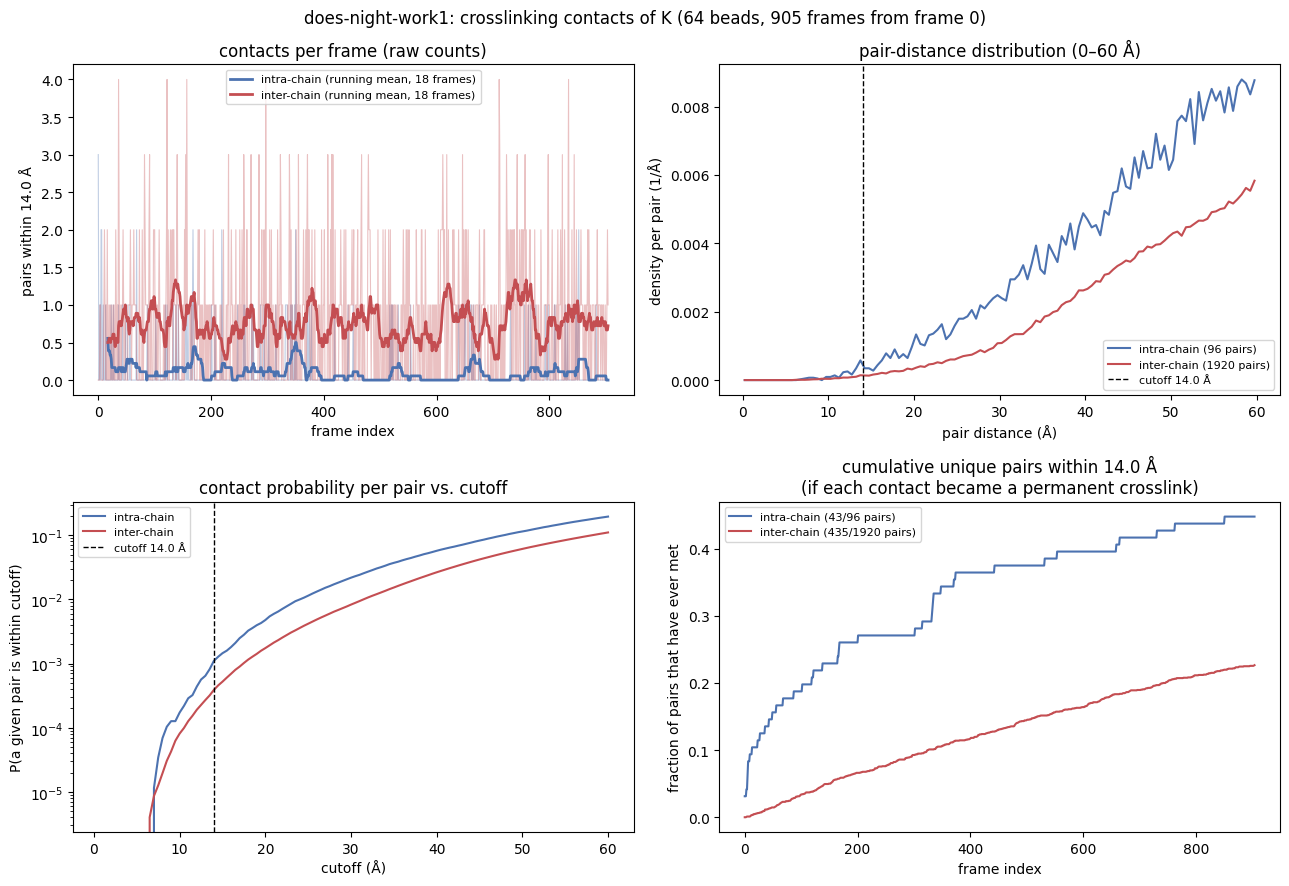

In [3]:
intra_color, inter_color = "#4c72b0", "#c44e52"
bin_centers_c = 0.5 * (hist_bins[:-1] + hist_bins[1:])
frames_axis = frame_indices

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Contacts over time — raw counts, i.e. how many crosslinkable pairs are
# simultaneously within the cutoff in each saved frame.
ax = axes[0, 0]
ax.plot(frames_axis, intra_per_frame, color=intra_color, alpha=0.35, linewidth=0.8)
ax.plot(frames_axis, inter_per_frame, color=inter_color, alpha=0.35, linewidth=0.8)
window = max(1, n_frames_contact // 50)
if window > 1:
    kernel = np.ones(window) / window
    ax.plot(frames_axis[window - 1:], np.convolve(intra_per_frame, kernel, mode="valid"),
            color=intra_color, linewidth=2, label=f"intra-chain (running mean, {window} frames)")
    ax.plot(frames_axis[window - 1:], np.convolve(inter_per_frame, kernel, mode="valid"),
            color=inter_color, linewidth=2, label=f"inter-chain (running mean, {window} frames)")
else:
    ax.plot([], [], color=intra_color, label="intra-chain")
    ax.plot([], [], color=inter_color, label="inter-chain")
ax.set_xlabel("frame index")
ax.set_ylabel(f"pairs within {contact_cutoff} Å")
ax.set_title("contacts per frame (raw counts)")
ax.legend(fontsize=8)

# (2) Distance distribution, normalized per pair so the two classes are directly
# comparable despite there being many more inter-chain pairs than intra-chain ones.
ax = axes[0, 1]
if n_intra_pairs:
    ax.plot(bin_centers_c, hist_intra / (n_intra_pairs * n_frames_contact * hist_bin),
            color=intra_color, label=f"intra-chain ({n_intra_pairs} pairs)")
if n_inter_pairs:
    ax.plot(bin_centers_c, hist_inter / (n_inter_pairs * n_frames_contact * hist_bin),
            color=inter_color, label=f"inter-chain ({n_inter_pairs} pairs)")
ax.axvline(contact_cutoff, color="black", linestyle="--", linewidth=1, label=f"cutoff {contact_cutoff} Å")
ax.set_xlabel("pair distance (Å)")
ax.set_ylabel("density per pair (1/Å)")
ax.set_title(f"pair-distance distribution (0–{hist_max:.0f} Å)")
ax.legend(fontsize=8)

# (3) Cutoff scan — the same answer for every cutoff, so you can see whether the
# intra/inter verdict is an artefact of the particular contact_cutoff chosen above.
ax = axes[1, 0]
if n_intra_pairs:
    ax.plot(hist_bins[1:], np.cumsum(hist_intra) / (n_intra_pairs * n_frames_contact),
            color=intra_color, label="intra-chain")
if n_inter_pairs:
    ax.plot(hist_bins[1:], np.cumsum(hist_inter) / (n_inter_pairs * n_frames_contact),
            color=inter_color, label="inter-chain")
ax.axvline(contact_cutoff, color="black", linestyle="--", linewidth=1, label=f"cutoff {contact_cutoff} Å")
ax.set_yscale("log")
ax.set_xlabel("cutoff (Å)")
ax.set_ylabel("P(a given pair is within cutoff)")
ax.set_title("contact probability per pair vs. cutoff")
ax.legend(fontsize=8)

# (4) If every contact froze into a permanent crosslink, this is the fraction of
# pairs of each class that would have reacted by frame t.
ax = axes[1, 1]
for mask, n_pairs_cls, color, label in (
    (same_chain, n_intra_pairs, intra_color, "intra-chain"),
    (~same_chain, n_inter_pairs, inter_color, "inter-chain"),
):
    if not n_pairs_cls:
        continue
    first = first_hit_frame[mask]
    reacted = np.cumsum(np.bincount(first[first >= 0], minlength=n_frames_contact))
    ax.plot(frames_axis, reacted / n_pairs_cls, color=color,
            label=f"{label} ({np.count_nonzero(first >= 0)}/{n_pairs_cls} pairs)")
ax.set_xlabel("frame index")
ax.set_ylabel("fraction of pairs that have ever met")
ax.set_title(f"cumulative unique pairs within {contact_cutoff} Å\n(if each contact became a permanent crosslink)")
ax.legend(fontsize=8)

fig.suptitle(f"{sim_name}: crosslinking contacts of {'/'.join(contact_letters)} "
             f"({contact_ca.n_atoms} beads, {n_frames_contact} frames from frame {contact_start_frame})")
fig.tight_layout()
save_figure(sim_name, f"crosslink_contacts_{'_'.join(contact_letters)}", fig)
plt.show()


## Crosslinks actually formed: K–K (intra vs. inter) and to the ground, over time

The cells above count **contacts** — pairs that came close enough to react.
This one counts the bonds the run actually **made**, read from its own
`runtime/crosslink_events.csv`: `kind = intra`/`inter` for a lysine–lysine
crosslink, `kind = surface` for a lysine pinned to the ground, and
`origin = initial` for the surface bonds a free/preattached run *starts* with
versus `origin = run` for the ones it formed. Nothing here ever breaks a bond,
so every curve only goes up and its last value is the yield.

The numbers:

* **K–K crosslinks**, split **intra-chain** (a loop closed inside one polymer)
  vs **inter-chain** (a bridge between two — the only ones that build a
  network);
* **K–surface bonds**, split into the ones present at t = 0 and the ones formed
  during the run;
* how many of the system's lysines each of those consumed, and how many are
  still unreacted — the budget everything above is competing for;
* how many chains ended up bridged to another chain, and the largest group of
  chains connected through inter-chain crosslinks.

And four plots: bonds over time (cumulative), when they formed, the lysine
budget, and how the connected network grew. A run with no
`crosslink_events.csv` — a plain brush, or crosslinking switched off — says so
and plots nothing.

Bond *times* are not kinetics: CALVADOS has no crosslinker, no solvent and no
activation barrier, so what is meaningful here is the sequence, the counts and
the intra/inter split, not the rate. See the caveats in `tools/crosslink.py`.


In [ ]:
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from tools.metadata import as_float, read_metadata

# ---- Inputs --------------------------------------------------------------
formed_windows = 40      # number of time windows in the "bonds formed per window" panel
# ---------------------------------------------------------------------------

with save_text(sim_name, "crosslinks_formed"):
    # Bonds that the *run* actually made, read from its own event log — not the
    # geometric contacts of the cells above. A contact is two lysines that came
    # close; a bond here is one the reactor committed to and never released, so
    # these counts only ever go up and the final number is the yield.
    runtime_dir = Path(f"simulations/{sim_name}/runtime")
    meta = read_metadata(runtime_dir)
    events_path = runtime_dir / "crosslink_events.csv"

    event_rows = []
    if events_path.is_file():
        with open(events_path, newline="") as f:
            event_rows = list(csv.DictReader(f))

    n_frames_xl = len(u.trajectory)

    # x axis in ns where the run recorded enough to convert, frames otherwise.
    ps_per_frame = as_float(meta, "time_per_frame_ps")
    if not np.isfinite(ps_per_frame):
        ps_per_frame = as_float(meta, "steps_per_frame") * as_float(meta, "timestep_ps", 0.01)
    in_ns = np.isfinite(ps_per_frame) and ps_per_frame > 0
    x_axis = np.arange(n_frames_xl) * (ps_per_frame / 1000.0 if in_ns else 1.0)
    x_label = "time (ns)" if in_ns else "frame index"

    def at_frame(row):
        """The saved frame an event belongs to, clipped into the trajectory.

        Reactions are checked more often than frames are saved, so the logged
        frame is a rounded step count and the last one can land just past the
        final saved frame (or past a trajectory that was cut short).
        """
        try:
            frame = int(round(float(row.get("frame") or 0)))
        except ValueError:
            frame = 0
        return int(np.clip(frame, 0, max(n_frames_xl - 1, 0)))

    def site(row, end):
        """(chain, resid) of one end of a bond — the identity of a single lysine."""
        return (row.get(f"chain_{end}", ""), row.get(f"resid_{end}", ""))

    # `origin` was added to the log later; a file without it only ever holds
    # bonds formed during the run (initial bonds are a surface-mode thing).
    kk = [r for r in event_rows if (r.get("kind") or "").strip() in ("intra", "inter")]
    surface = [r for r in event_rows if (r.get("kind") or "").strip() == "surface"]
    intra = [r for r in kk if r["kind"].strip() == "intra"]
    inter = [r for r in kk if r["kind"].strip() == "inter"]
    surface_initial = [r for r in surface if (r.get("origin") or "run").strip() == "initial"]
    surface_run = [r for r in surface if (r.get("origin") or "run").strip() != "initial"]

    # How many lysines there were to spend, counted in the topology that was
    # actually simulated (metadata's lysines_total is the same number, when the
    # run got far enough to write it).
    n_lys_per_chain = sum(1 for res in chains[0].residues if res.resname == "LYS")
    n_lys = n_lys_per_chain * n_chains

    kk_lysines = {site(r, end) for r in kk for end in ("i", "j")}
    surface_lysines = {site(r, "i") for r in surface}
    both = kk_lysines & surface_lysines

    print(f"{sim_name}: bonds actually formed (mode {mode}, {n_frames_xl} frames"
          + (f", {x_axis[-1]:.1f} ns)" if in_ns and n_frames_xl else ")"))
    print(f"  lysines in the system:      {n_lys}  ({n_chains} chains x {n_lys_per_chain})")
    print(f"  K–K crosslinks:             {len(kk)}"
          + (f"   using {len(kk_lysines)} lysines ({len(kk_lysines) / n_lys:.1%})" if n_lys else ""))
    print(f"     intra-chain (loops):     {len(intra)}"
          + (f"  ({len(intra) / len(kk):.1%} of K–K bonds)" if kk else ""))
    print(f"     inter-chain (bridges):   {len(inter)}"
          + (f"  ({len(inter) / len(kk):.1%} of K–K bonds)" if kk else ""))
    print(f"  K–surface bonds (ground):   {len(surface)}"
          + (f"   using {len(surface_lysines)} lysines ({len(surface_lysines) / n_lys:.1%})" if n_lys else ""))
    print(f"     present at t=0:          {len(surface_initial)}")
    print(f"     formed during the run:   {len(surface_run)}")
    if n_lys:
        free = n_lys - len(kk_lysines | surface_lysines)
        print(f"  lysines still unreacted:    {free}  ({free / n_lys:.1%})")
    if both:
        print(f"  !  {len(both)} lysine(s) appear in both a K–K and a surface bond — "
              f"the two reactors are supposed to mask each other out")

    if not event_rows:
        print("  no crosslink_events.csv in runtime/ — this run had no reactive chemistry "
              "(plain brush / crosslinking off), so there is nothing to plot.")
    else:
        # ---- Time series ---------------------------------------------------
        def per_frame(rows_):
            counts = np.zeros(n_frames_xl, dtype=int)
            for r in rows_:
                counts[at_frame(r)] += 1
            return counts

        def lysines_per_frame(rows_, ends):
            """New lysines consumed per frame — a lysine is only counted the first
            time it reacts, so valence > 1 doesn't double-count it."""
            counts = np.zeros(n_frames_xl, dtype=int)
            seen = set()
            for r in sorted(rows_, key=at_frame):
                for end in ends:
                    if site(r, end) not in seen:
                        seen.add(site(r, end))
                        counts[at_frame(r)] += 1
            return counts

        new_intra, new_inter = per_frame(intra), per_frame(inter)
        new_surface = per_frame(surface)
        # The bonds a run *made*, for the rate panel: the initial surface bonds are
        # the starting condition, and plotting them as a spike at t=0 squashes
        # everything the run actually did onto the axis.
        new_surface_run = per_frame(surface_run)
        cum_intra, cum_inter = np.cumsum(new_intra), np.cumsum(new_inter)
        cum_kk = cum_intra + cum_inter
        cum_surface = np.cumsum(new_surface)
        cum_kk_lys = np.cumsum(lysines_per_frame(kk, ("i", "j")))
        cum_surface_lys = np.cumsum(lysines_per_frame(surface, ("i",)))

        # Network growth: chains joined by inter-chain bonds, union-find over the
        # events in time order. "Connected" is what turns a set of crosslinks into
        # a gel, and it is not readable off the bond count alone — twelve bridges
        # between the same two chains build nothing.
        parent = list(range(n_chains))

        def root(a):
            while parent[a] != a:
                parent[a] = parent[parent[a]]
                a = parent[a]
            return a

        bridged = np.zeros(n_frames_xl, dtype=int)      # chains with >= 1 inter-chain bond
        largest = np.zeros(n_frames_xl, dtype=int)      # size of the biggest connected group
        touched: set[int] = set()
        by_frame: dict[int, list[dict]] = {}
        for r in inter:
            by_frame.setdefault(at_frame(r), []).append(r)
        for f in range(n_frames_xl):
            for r in by_frame.get(f, ()):
                try:
                    a, b = int(r["chain_i"]), int(r["chain_j"])
                except (TypeError, ValueError):
                    continue
                if not (0 <= a < n_chains and 0 <= b < n_chains):
                    continue
                touched.update((a, b))
                ra, rb = root(a), root(b)
                if ra != rb:
                    parent[ra] = rb
            bridged[f] = len(touched)
            sizes: dict[int, int] = {}
            for c in touched:
                r_ = root(c)
                sizes[r_] = sizes.get(r_, 0) + 1
            largest[f] = max(sizes.values(), default=0)

        first_bond = next((at_frame(r) for r in sorted(event_rows, key=at_frame)
                           if (r.get("origin") or "run").strip() != "initial"), None)
        last_bond = max((at_frame(r) for r in event_rows
                         if (r.get("origin") or "run").strip() != "initial"), default=None)
        unit = (lambda f: f"{x_axis[f]:.1f} ns") if in_ns else (lambda f: f"frame {f}")
        if first_bond is not None:
            print(f"  first bond formed at        {unit(first_bond)} (frame {first_bond}), "
                  f"last at {unit(last_bond)} (frame {last_bond})")
        if n_frames_xl and cum_kk[-1]:
            half = int(np.searchsorted(cum_kk, cum_kk[-1] / 2))
            print(f"  half the K–K bonds by       {unit(half)} (frame {half})")
        print(f"  chains bridged to another:  {bridged[-1]} of {n_chains}, "
              f"largest connected group {largest[-1]} chains")

        # ---- Plots ---------------------------------------------------------
        kk_color, intra_color, inter_color, surf_color = "#8172b2", "#4c72b0", "#c44e52", "#55a868"
        fig, axes = plt.subplots(2, 2, figsize=(13, 9))

        # (1) The headline: how many bonds exist at each point in the run.
        ax = axes[0, 0]
        ax.plot(x_axis, cum_kk, color=kk_color, linewidth=2, label=f"K–K total ({cum_kk[-1]})")
        ax.plot(x_axis, cum_intra, color=intra_color, label=f"K–K intra-chain ({cum_intra[-1]})")
        ax.plot(x_axis, cum_inter, color=inter_color, label=f"K–K inter-chain ({cum_inter[-1]})")
        ax.plot(x_axis, cum_surface, color=surf_color, label=f"K–surface ({cum_surface[-1]})")
        ax.set_xlabel(x_label)
        ax.set_ylabel("bonds formed (cumulative)")
        ax.set_title("crosslinks formed over time")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # (2) When they formed — a run that stopped reacting early is flat here
        # long before the cumulative curve looks saturated.
        ax = axes[0, 1]
        edges = np.linspace(0, max(n_frames_xl - 1, 1), min(formed_windows, max(n_frames_xl, 2)) + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])
        width = (edges[1] - edges[0])
        scale = (ps_per_frame / 1000.0) if in_ns else 1.0
        bottom = np.zeros(len(centers))
        for counts, color, label in ((new_intra, intra_color, "K–K intra-chain"),
                                     (new_inter, inter_color, "K–K inter-chain"),
                                     (new_surface_run, surf_color, "K–surface (formed in run)")):
            binned = np.histogram(np.arange(n_frames_xl), bins=edges, weights=counts)[0]
            ax.bar(centers * scale, binned, bottom=bottom, width=width * scale * 0.9,
                   color=color, label=label)
            bottom += binned
        ax.set_xlabel(x_label)
        ax.set_ylabel(f"bonds formed per window ({width:.0f} frames)")
        ax.set_title("formation rate")
        ax.legend(fontsize=8)

        # (3) The lysine budget: bonds are capped by the number of lysines, so the
        # fraction consumed says how much chemistry the run had left in it.
        ax = axes[1, 0]
        if n_lys:
            ax.plot(x_axis, 100 * cum_kk_lys / n_lys, color=kk_color, label="in a K–K crosslink")
            ax.plot(x_axis, 100 * cum_surface_lys / n_lys, color=surf_color, label="bonded to the surface")
            ax.plot(x_axis, 100 * (n_lys - cum_kk_lys - cum_surface_lys) / n_lys,
                    color="#888888", linestyle="--", label="still free")
            ax.set_ylim(0, 100)
        ax.set_xlabel(x_label)
        ax.set_ylabel(f"% of the {n_lys} lysines")
        ax.set_title("lysine budget over time")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # (4) Bonds are not yet a network: this is the part that gels.
        ax = axes[1, 1]
        ax.plot(x_axis, bridged, color=inter_color, label="chains with >= 1 inter-chain bond")
        ax.plot(x_axis, largest, color="#dd8452", label="largest connected group")
        ax.axhline(n_chains, color="black", linestyle="--", linewidth=1, label=f"all {n_chains} chains")
        ax.set_xlabel(x_label)
        ax.set_ylabel("chains")
        ax.set_ylim(0, n_chains * 1.1)
        ax.set_title("network growth (inter-chain crosslinks only)")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        fig.suptitle(f"{sim_name}: lysine bonds formed during the run "
                     f"({len(kk)} K–K, {len(surface)} K–surface)")
        fig.tight_layout()
        save_figure(sim_name, "crosslinks_formed", fig)
        plt.show()


## Surface bonds (free / preattached modes)

For a run whose chains hang from their lysines (`mode` free or preattached),
`crosslink_events.csv` also records every lysine–surface bond: `kind = surface`,
with `origin = initial` for the ones the run started with and `origin = run` for
the ones it formed. This cell reports, for this run:

* how many lysines are surface-bonded, as a count and as a fraction of all
  lysines;
* how many chains have one, two, or three-plus surface bonds — the number that
  says whether the result is a **coating** (many pins per chain) or a set of
  **loosely tethered chains** (one pin each);
* for a run that allowed binding, when bonds formed and whether the global cap
  was reached;
* where the pins sit on the surface, to check they are spread rather than
  clustered.

A brush-mode run has none of this and the cell says so. Event *times* are not
kinetics — see the caveats in `tools/surface.py`.

In [ ]:
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from tools.metadata import as_float, read_metadata
from tools.surface import summarize_event_rows

with save_text(sim_name, "surface_bonds"):
    runtime_dir = Path(f"simulations/{sim_name}/runtime")
    meta = read_metadata(runtime_dir)
    events_path = runtime_dir / "crosslink_events.csv"
    rows = []
    if events_path.is_file():
        with open(events_path, newline="") as f:
            rows = list(csv.DictReader(f))
    surface_rows = [r for r in rows if r.get("kind") == "surface"]

    if mode == "brush" or not surface_rows:
        print(f"{sim_name}: mode {mode} — no lysine-surface bonds "
              + ("(residue 0 is the fixed anchor)." if mode == "brush" else "recorded."))
    else:
        n_lys_per_chain = sum(1 for res in chains[0].residues if res.resname == "LYS")
        n_lys = n_lys_per_chain * n_chains
        stats = summarize_event_rows(rows, n_chains)
        steps_per_frame = as_float(meta, "steps_per_frame", default=np.nan)
        cap_fraction = as_float(meta, "surface_max_fraction", default=np.nan)
        cap_step = meta.get("surface_cap_reached_step", "")
        dynamic = (meta.get("surface_dynamic", "") or "").lower() == "true"

        per_chain_initial = np.zeros(n_chains, dtype=int)
        per_chain_run = np.zeros(n_chains, dtype=int)
        for r in surface_rows:
            (per_chain_initial if r.get("origin") == "initial" else per_chain_run)[int(r["chain_i"])] += 1
        per_chain = per_chain_initial + per_chain_run

        print(f"{sim_name}: mode {mode}")
        print(f"  lysines:              {n_lys} ({n_lys_per_chain} per chain x {n_chains} chains)")
        print(f"  surface-bonded:       {stats['surface_bonds']}  = {stats['surface_bonds'] / n_lys:.3f} of all lysines")
        print(f"    at t=0:             {stats['surface_bonds_initial']}")
        print(f"    formed in the run:  {stats['surface_bonds_run']}")
        print(f"  chains with 1 bond:   {stats['chains_with_1']}")
        print(f"  chains with 2 bonds:  {stats['chains_with_2']}")
        print(f"  chains with 3+ bonds: {stats['chains_with_3plus']}")
        if stats["chains_with_0"]:
            print(f"  ⚠ chains with 0 bonds: {stats['chains_with_0']} — every chain should have one")
        print(f"  bonds per chain:      min {per_chain.min()}, mean {per_chain.mean():.2f}, max {per_chain.max()}")
        if np.isfinite(cap_fraction):
            print(f"  global cap:           {cap_fraction:g} of all lysines = {int(cap_fraction * n_lys)} bonds"
                  + (f", reached at step {cap_step}" if cap_step not in ("", None) else
                     (", not reached" if dynamic else " (binding during the run was off)")))
        if per_chain.max() >= 3 and stats["chains_with_3plus"] >= n_chains / 2:
            print("  -> most chains are held at three or more points: this is a coating.")
        elif per_chain.max() == 1:
            print("  -> every chain hangs from a single lysine: loosely tethered chains, not a coating.")

        fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

        # (1) bonds per chain, initial vs formed
        ax = axes[0]
        x = np.arange(n_chains)
        ax.bar(x, per_chain_initial, color="#4c72b0", label="at t=0")
        ax.bar(x, per_chain_run, bottom=per_chain_initial, color="#dd8452", label="formed in the run")
        ax.set_xlabel("chain")
        ax.set_ylabel("surface bonds")
        ax.set_title("surface bonds per chain")
        ax.legend(fontsize=8)

        # (2) cumulative bonds over time
        ax = axes[1]
        times = np.array(sorted(float(r["time_ps"]) for r in surface_rows))
        use_ns = times.max() >= 1000
        ax.step(times / (1000 if use_ns else 1), np.arange(1, len(times) + 1), where="post", color="#4c72b0")
        ax.axhline(stats["surface_bonds_initial"], color="#4c72b0", linestyle=":", linewidth=1,
                   label="bonds at t=0")
        if np.isfinite(cap_fraction):
            ax.axhline(int(cap_fraction * n_lys), color="#c44e52", linestyle="--", linewidth=1,
                       label=f"cap ({cap_fraction:g} of {n_lys})")
        ax.set_xlabel("simulated time (ns)" if use_ns else "simulated time (ps)")
        ax.set_ylabel("surface-bonded lysines")
        ax.set_title("surface bonds over time" + ("" if dynamic else " (binding off)"))
        ax.legend(fontsize=8)

        # (3) where the pins are (nm, as recorded), on the box footprint
        ax = axes[2]
        box_nm = box[:2] / 10.0
        for origin, color, label in (("initial", "#4c72b0", "at t=0"), ("run", "#dd8452", "formed in the run")):
            pts = np.array([[float(r["x"]), float(r["y"])] for r in surface_rows if r.get("origin") == origin])
            if len(pts):
                pts = np.mod(pts, box_nm)
                ax.scatter(pts[:, 0], pts[:, 1], s=18, color=color, label=label)
        ax.set_xlim(0, box_nm[0])
        ax.set_ylim(0, box_nm[1])
        ax.set_aspect("equal")
        ax.set_xlabel("x (nm)")
        ax.set_ylabel("y (nm)")
        ax.set_title("pins on the surface (wrapped into the box)")
        ax.legend(fontsize=8)

        fig.suptitle(f"{sim_name}: {stats['surface_bonds']} of {n_lys} lysines bonded to the surface "
                     f"({stats['surface_bonds'] / n_lys:.2f}); chains with 1/2/3+ bonds: "
                     f"{stats['chains_with_1']}/{stats['chains_with_2']}/{stats['chains_with_3plus']}")
        fig.tight_layout()
        save_figure(sim_name, "surface_bonds", fig)
        plt.show()


## Run the whole Analyze section over every run in `ANALYZE`

Repeats every cell of this section — all the ones tagged `analysis`, in order —
once per simulation resolved at the top, with `sim_name` rebound each time.
There is no second copy of the analysis to keep in sync: these are literally
the cells above, read from the saved notebook, so **save the notebook** after
editing one of them and before running this.

Each run's output lands in its own `simulations/<name>/analysis/` (text and
PNGs, see `tools/analysis_io.py`), which is what you commit and read back on
DelftBlue. A run whose cells raise is reported and abandoned — the batch
carries on with the next name rather than analyzing it with the previous run's
trajectory still loaded — and at the end you get one line per run that did not
finish.


In [ ]:
import matplotlib

from tools.analysis_batch import run_for_each

SHOW_BATCH_PLOTS = 0   # 1 to also draw every figure in the notebook; they are saved either way

# Twenty runs x a dozen figures each is an unusable notebook and a lot of
# memory, and every figure is written to analysis/ regardless — so by default
# draw into files only, and put the interactive backend back afterwards.
_backend = matplotlib.get_backend()
if not SHOW_BATCH_PLOTS:
    matplotlib.use("Agg")
try:
    batch_results = run_for_each(sim_names, globals())
finally:
    matplotlib.use(_backend)
